# TNMH in action — the phase-transition sweep

The Tensor-Network Metropolis–Hastings sampler run across temperatures, reproducing the
2D Ising phase transition. We measure the **acceptance rate** and **energy per site** vs β
for L = 16, 32, 64, and see the acceptance dip near β_c deepen with system size — the same
behaviour reported in SciPost Phys. 14, 123 (2023).

*(The full sweep is slow — 16×16 ≈ 35 min up to 64×64 ≈ 11 h. The results are already saved
in `ising_mcmc_results_D2.jld2`; to just view them, skip to the reload-and-plot cells.)*

In [ ]:
using ITensors, ITensorMPS, ProgressMeter, Plots, LinearAlgebra

include("main.jl")

In [2]:
# Parameters to sweep
L_values = [16, 32, 64]
beta_values = vcat(
    range(0.3, stop=0.4, length=2),
    range(0.41, stop=0.48, length=4),
    range(0.5, stop=0.6, length=2)
)

D_bound = 2
N_samples = 2000 

# Dictionaries to store results
results_acc = Dict(L => Float64[] for L in L_values)
results_e = Dict(L => Float64[] for L in L_values)

Dict{Int64, Vector{Float64}} with 3 entries:
  32 => []
  64 => []
  16 => []

In [3]:
println("Starting Phase Transition Sweep for D_bound=$D_bound")
println("Betas: ", beta_values)

for L in L_values
    println("\n--- Running for Grid $(L)x$(L) ---")
    
    @showprogress "L=$L Sweep: " for beta in beta_values
        acc, e = run_mcmc_sweep(L, L, beta, D_bound, N_samples)
        push!(results_acc[L], acc)
        push!(results_e[L], e)
    end
end

Starting Phase Transition Sweep for D_bound=2
Betas: [0.3, 0.4, 0.41, 0.43333333333333335, 0.45666666666666667, 0.48, 0.5, 0.6]

--- Running for Grid 16x16 ---


L=16 Sweep: 100%|███████████████████████████████████████| Time: 0:35:06



--- Running for Grid 32x32 ---


L=32 Sweep: 100%|███████████████████████████████████████| Time: 2:29:24



--- Running for Grid 64x64 ---


L=64 Sweep: 100%|███████████████████████████████████████| Time: 10:58:04


In [13]:
using JLD2

output_file = "ising_mcmc_results_D$(D_bound).jld2"

jldsave(output_file; 
    results_acc = results_acc,
    results_e = results_e,
    beta_values = beta_values,
    L_values = L_values,
    D_bound = D_bound,
    N_samples = N_samples
)

**Reload the saved sweep and plot** acceptance rate & ⟨E⟩/N vs β (with β_c marked).

In [ ]:
using JLD2

filename = "ising_mcmc_results_D2.jld2"

@load filename results_acc results_e beta_values L_values D_bound N_samples

6-element Vector{Symbol}:
 :results_acc
 :results_e
 :beta_values
 :L_values
 :D_bound
 :N_samples

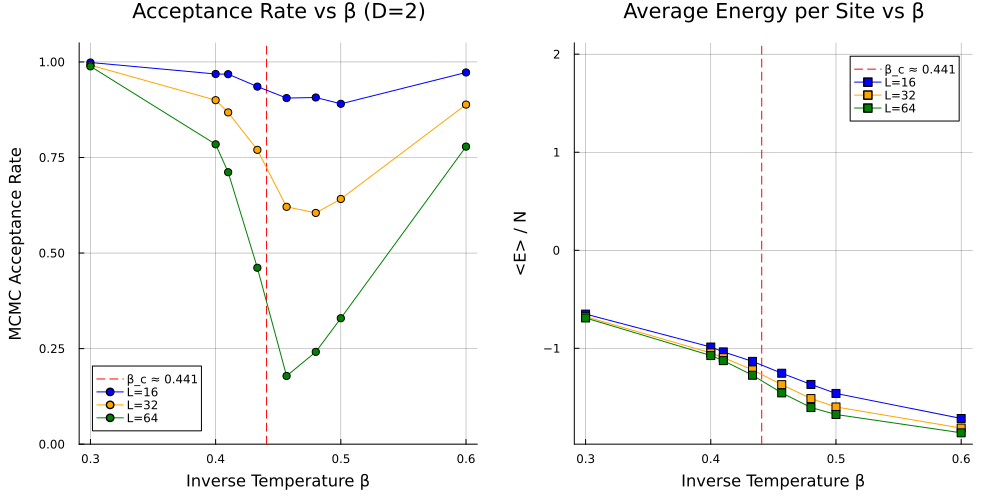

In [7]:
# PLOTTING
beta_c_analytical = log(1 + sqrt(2)) / 2  # ~ 0.44068

p1 = plot(title="Acceptance Rate vs β (D=$D_bound)", xlabel="Inverse Temperature β", ylabel="MCMC Acceptance Rate", ylims=(0, 1.05), grid=true, gridalpha=0.4, legend=:bottomleft)
p2 = plot(title="Average Energy per Site vs β", xlabel="Inverse Temperature β", ylabel="<E> / N", grid=true, gridalpha=0.4, legend=:topright)

# Analytical critical lines
vline!(p1, [beta_c_analytical], color=:red, linestyle=:dash, label="β_c ≈ 0.441")
vline!(p2, [beta_c_analytical], color=:red, linestyle=:dash, label="β_c ≈ 0.441")

colors = [:blue, :orange, :green]

# Plot the data
for (idx, L) in enumerate(L_values)
    plot!(p1, beta_values, results_acc[L], marker=:circle, color=colors[idx], label="L=$L")
    plot!(p2, beta_values, results_e[L], marker=:square, color=colors[idx], label="L=$L")
end

# Combine layouts side-by-side
plot(p1, p2, layout=(1, 2), size=(1000, 500), margin=5Plots.mm)